In [ ]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

# 🧪 Étape 6 : Évaluation Métrique & Robustesse (Squelette Étudiant)

Cette étape correspond au sixième chapitre du cours. L'objectif est de mettre en place un protocole d'évaluation rigoureux (splits d'évaluation adaptés) et de calculer les métriques clés de performance pour valider scientifiquement la qualité de vos modèles.

### 1. Préparation de l'environnement

On importe les outils nécessaires pour évaluer nos modèles et mesurer
leur performance de manière rigoureuse.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, classification_report, confusion_matrix)

%matplotlib inline
print("Librairies prêtes pour l'évaluation des modèles !")

Librairies prêtes pour l'évaluation des modèles !


### 2. Évaluation du modèle Tabulaire

On charge les données, on ré-entraîne les modèles et on compare leurs performances
avec 3 métriques clés : **MAE**, **RMSE** et **R²**.

In [2]:
# Chargement et préparation des données
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')
df['power_to_weight'] = df['horsepower'] / df['weight']

X = df.drop(columns=['mpg'])
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entraînement des 2 modèles
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Tableau comparatif des métriques
results = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Random Forest'],
    'MAE': [
        round(mean_absolute_error(y_test, y_pred_lr), 3),
        round(mean_absolute_error(y_test, y_pred_rf), 3)
    ],
    'RMSE': [
        round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 3),
        round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 3)
    ],
    'R²': [
        round(r2_score(y_test, y_pred_lr), 3),
        round(r2_score(y_test, y_pred_rf), 3)
    ]
})

print(results.to_string(index=False))

             Modèle   MAE  RMSE    R²
Régression Linéaire 2.321 2.890 0.845
      Random Forest 1.611 2.155 0.914


#### Comparaison des modèles

| Modèle | MAE | RMSE | R² |
|---|---|---|---|
| Régression Linéaire | 2.321 | 2.890 | 0.845 |
| **Random Forest** | **1.611** | **2.155** | **0.914** |

Le **Random Forest est clairement meilleur** sur les 3 métriques.
Un R² de 0.91 signifie qu'il explique 91% de la variation du MPG.
La MAE de 1.61 MPG montre que les prédictions sont très proches des vraies valeurs.

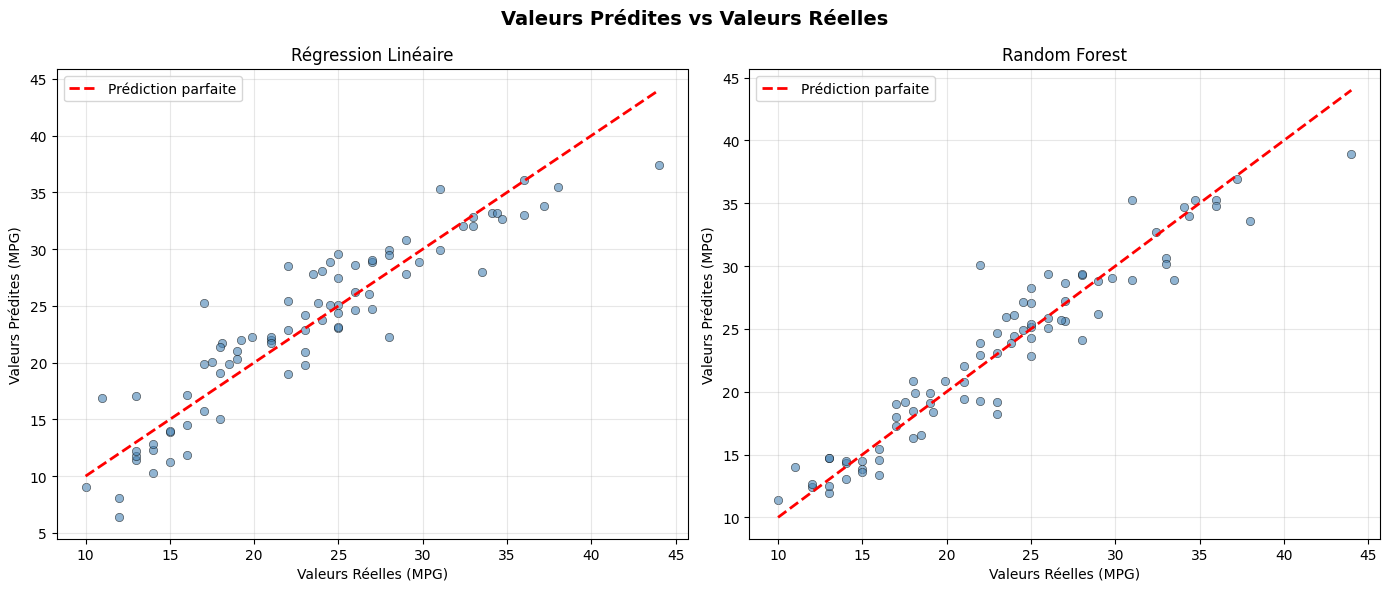

In [3]:
# Graphique : Valeurs prédites vs valeurs réelles
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Régression Linéaire', 'Random Forest']
):
    ax.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.5)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Prédiction parfaite')
    ax.set_xlabel('Valeurs Réelles (MPG)')
    ax.set_ylabel('Valeurs Prédites (MPG)')
    ax.set_title(f'{title}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Valeurs Prédites vs Valeurs Réelles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/predicted_vs_actual.png')
plt.show()

### 3. Protocole de Validation Croisée (Out-of-Fold / Chronologique)

La validation croisée permet de vérifier que notre modèle fonctionne bien
sur **toutes les parties du dataset**, pas seulement sur un seul découpage.

On utilise **K-Fold avec k=5** : on divise les données en 5 parties,
on entraîne 5 fois en changeant à chaque fois quelle partie sert de test.
Cela donne une mesure plus fiable de la performance réelle du modèle.

**Pourquoi pas un split chronologique ?**
Notre dataset Automobile n'est pas une série temporelle — les voitures
ne sont pas liées dans le temps. Un K-Fold aléatoire est donc plus adapté.

In [4]:
# Validation croisée K-Fold (k=5)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = RandomForestRegressor(n_estimators=100, random_state=42)

cv_r2 = cross_val_score(rf_cv, X, y, cv=kfold, scoring='r2')
cv_mae = cross_val_score(rf_cv, X, y, cv=kfold,
                         scoring='neg_mean_absolute_error')

print("=== Résultats Validation Croisée (5 Folds) ===")
print(f"\nR² par fold    : {[round(x, 3) for x in cv_r2]}")
print(f"R² moyen       : {cv_r2.mean():.3f} (+/- {cv_r2.std():.3f})")
print(f"\nMAE par fold   : {[round(-x, 3) for x in cv_mae]}")
print(f"MAE moyenne    : {(-cv_mae).mean():.3f} (+/- {cv_mae.std():.3f})")

=== Résultats Validation Croisée (5 Folds) ===

R² par fold    : [np.float64(0.908), np.float64(0.872), np.float64(0.844), np.float64(0.84), np.float64(0.876)]
R² moyen       : 0.868 (+/- 0.025)

MAE par fold   : [np.float64(1.668), np.float64(1.976), np.float64(2.065), np.float64(2.195), np.float64(1.998)]
MAE moyenne    : 1.980 (+/- 0.174)


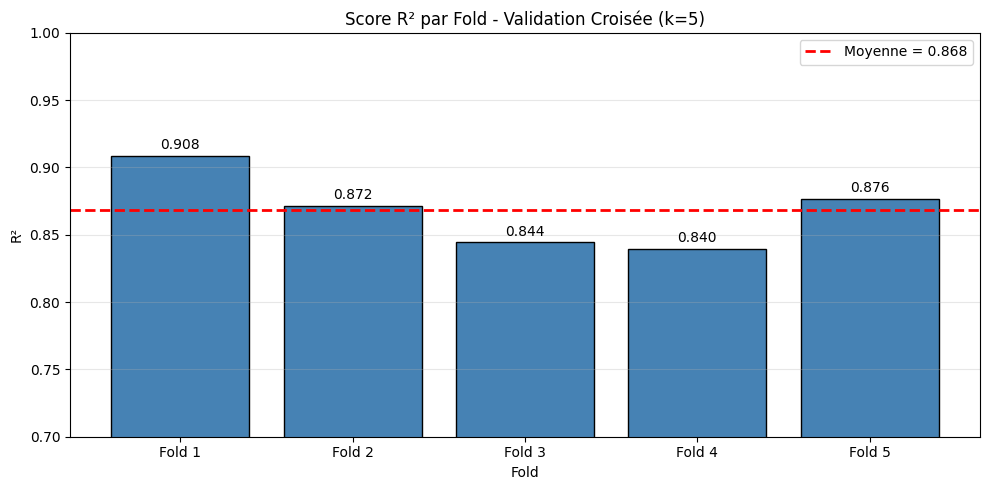

In [5]:
# Graphique des R² par fold
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [f'Fold {i+1}' for i in range(5)],
    cv_r2,
    color='steelblue',
    edgecolor='black'
)
ax.axhline(y=cv_r2.mean(), color='red', linestyle='--',
           linewidth=2, label=f'Moyenne = {cv_r2.mean():.3f}')
ax.set_title('Score R² par Fold - Validation Croisée (k=5)')
ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.set_ylim(0.7, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, cv_r2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/cross_validation.png')
plt.show()

#### Interprétation des résultats

| Fold | R² | MAE |
|---|---|---|
| Fold 1 | 0.908 | 1.668 |
| Fold 2 | 0.872 | 1.976 |
| Fold 3 | 0.844 | 2.065 |
| Fold 4 | 0.840 | 2.195 |
| Fold 5 | 0.876 | 1.998 |
| **Moyenne** | **0.868 ± 0.025** | **1.980 ± 0.174** |

**Ce que ça nous dit :**

- Le R² moyen de **0.868** confirme que le modèle est solide sur tout le dataset
- L'écart-type de **0.025** est très faible — le modèle est **stable et cohérent**,
  il ne dépend pas d'un découpage particulier
- Le Fold 1 est le meilleur (0.908) et le Fold 4 le moins bon (0.840) —
  la différence est minime, ce qui prouve que le modèle **généralise bien**
- Ces résultats confirment que notre Random Forest est fiable et prêt
  pour être utilisé en production